In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#Task1-Load csv & display basic info
df = pd.read_csv('sales_data.csv')
df

,order_id,customer_name,order_date,category,sub_category,product_name,quantity,unit_price,total_price,region
0,1000,Caleb Davis,1/31/2025,Clothing,Jeans,Jeans Try,2,1197,2394,West
1,1001,Misty Herrera,5/5/2025,Clothing,Jeans,Jeans New,9,1509,13581,South
2,1002,Rick Soto,6/9/2025,Clothing,Shoes,Shoes Us,5,1046,5230,East
3,1003,Sean Haas,2/27/2025,Furniture,Desk,Desk Section,10,292,2920,South
4,1004,Ann Hall,6/1/2025,Furniture,Cabinet,Cabinet Center,2,548,1096,North
...,...,...,...,...,...,...,...,...,...,...
195,1195,Dylan Baxter,2/15/2025,Clothing,Jeans,Jeans Sound,7,798,5586,South
196,1196,Brandon Callahan,2/26/2025,Grocery,Snacks,Snacks Lead,3,3116,9348,East
197,1197,Angela Stanton,6/16/2025,Furniture,Cabinet,Cabinet None,1,1396,1396,South
198,1198,Marissa Aguilar,6/2/2025,Grocery,Milk,Milk Listen,6,461,2766,West


In [9]:
print(df.shape)

(200, 10)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
order_id         200 non-null int64
customer_name    200 non-null object
order_date       200 non-null object
category         200 non-null object
sub_category     200 non-null object
product_name     200 non-null object
quantity         200 non-null int64
unit_price       200 non-null int64
total_price      200 non-null int64
region           200 non-null object
dtypes: int64(4), object(6)
memory usage: 11.0+ KB


In [11]:
print(df.describe())

          order_id    quantity   unit_price   total_price
count   200.000000  200.000000   200.000000    200.000000
mean   1099.500000    4.910000  2421.495000  12100.535000
std      57.879185    3.017853  1464.016187  10915.548067
min    1000.000000    1.000000    79.000000     79.000000
25%    1049.750000    2.000000  1120.000000   3060.000000
50%    1099.500000    5.000000  2373.500000   8912.000000
75%    1149.250000    7.000000  3541.750000  19350.750000
max    1199.000000   10.000000  4997.000000  47940.000000


In [12]:
#task2_missing_duplicates
print(df.isnull().sum())

order_id         0
customer_name    0
order_date       0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
total_price      0
region           0
dtype: int64


In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [14]:
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
print(df_clean.shape)

(200, 10)


In [15]:
#Task3- group revene
revenue_by_category = (
    df_clean.groupby('category')['total_price']
    .sum()
    .sort_values(ascending=False)
)
print(revenue_by_category)


category
Furniture      714399
Grocery        672147
Electronics    549302
Clothing       484259
Name: total_price, dtype: int64


In [16]:
#Task4-sort columns
sorted_df = df_clean.sort_values(
    by=['region','total_price'],
    ascending=[True, False]
)
print(sorted_df[['order_id','customer_name','region','total_price']].head(10))

     order_id        customer_name region  total_price
125      1125        Lynn Garrison   East        47940
160      1160     Michelle Beltran   East        42471
190      1190    Christopher Meyer   East        37320
167      1167          Julie Adams   East        31108
115      1115          Gary Osborn   East        29124
59       1059  Miss Rebecca Levine   East        28764
157      1157        Patricia Gill   East        27405
24       1024           Jodi Smith   East        27066
6        1006     Breanna Gonzalez   East        26136
96       1096        Daniel Torres   East        25886


In [17]:
#Task5-correlation matrix
numeric_cols = df_clean.select_dtypes(include='number').drop(columns=['order_id'])
corr = numeric_cols.corr()
print(corr)

             quantity  unit_price  total_price
quantity     1.000000    0.047996     0.655212
unit_price   0.047996    1.000000     0.671318
total_price  0.655212    0.671318     1.000000


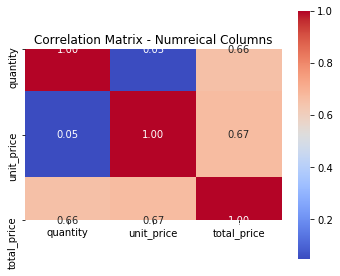

In [19]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix - Numreical Columns')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()